Model eğitiliyor...
Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1354
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4006e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.2679e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.4319e-04
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.9913e-04
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.2161e-04
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6986e-04
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.5913e-04
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━

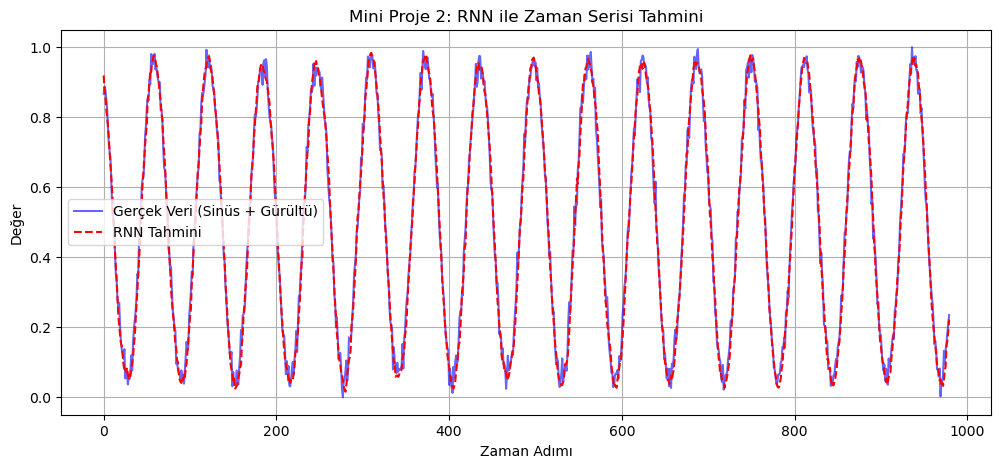

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input  # Input katmanı eklendi
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# 1. Veri Seti Oluşturma (Sinüs Dalgası)
# Sunum 12'deki zamansal verileri temsil eder
t = np.arange(0, 100, 0.1)
data = np.sin(t) + np.random.normal(0, 0.05, len(t)) 

# Veriyi [0, 1] arasına ölçeklendirme
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

# 2. Veriyi Pencereleme (Windowing) Yöntemiyle Hazırlama
def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 20  # Modelin geçmişe dönük bakacağı adım sayısı
X, y = create_dataset(data_scaled, look_back)

# RNN girişi için veriyi (samples, time_steps, features) formatına getirme
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 3. RNN Modeli Oluşturma (Modern Keras Yapısı)
# Bu yapı image_eec4aa.png dosyasında aldığın uyarıyı engeller.
model = Sequential([
    Input(shape=(look_back, 1)), # Giriş boyutunu burada tanımlıyoruz
    SimpleRNN(units=32, activation='tanh'),
    Dense(1)
])

# Gradient Clipping: Sunumun 5. maddesindeki çözümün koda dökülmüş hali
optimizer = Adam(learning_rate=0.001, clipvalue=0.5) 

model.compile(optimizer=optimizer, loss='mean_squared_error')

# 4. Eğitim
print("Model eğitiliyor...")
history = model.fit(X, y, epochs=20, batch_size=16, verbose=1)

# 5. Tahmin ve Görselleştirme
predictions = model.predict(X)

plt.figure(figsize=(12, 5))
plt.plot(y, label='Gerçek Veri (Sinüs + Gürültü)', color='blue', alpha=0.6)
plt.plot(predictions, label='RNN Tahmini', color='red', linestyle='--')
plt.title('Mini Proje 2: RNN ile Zaman Serisi Tahmini')
plt.xlabel('Zaman Adımı')
plt.ylabel('Değer')
plt.legend()
plt.grid(True)
plt.show()